## Regression Modeling – Initial Findings


The objective of this analysis is to evaluate how well song popularity on Spotify can be predicted using available audio features and artist-level metrics. This regression analysis supports the broader capstone goal of developing a data-driven decision-support system that helps artists estimate a song’s potential performance prior to release.

**Regression Models Evaluated**                            

The following regression models are implemented and compared:

*   Linear Regression (baseline)
*   Random Forest Regressor
*   Gradient Boosting Regressor


In [4]:
!pip -q install kagglehub

import kagglehub
import os
import pandas as pd

spotify_dir = kagglehub.dataset_download(
    "serkantysz/550k-spotify-songs-audio-lyrics-and-genres"
)

songs = pd.read_csv(
    os.path.join(spotify_dir, "songs.csv"),
    engine="python",
    on_bad_lines="skip"
)

artists = pd.read_csv(
    os.path.join(spotify_dir, "artists.csv"),
    engine="python",
    on_bad_lines="skip"
)


hits_2024_path = "/content/hits_2024.csv"

hits_2024 = pd.read_csv(
    hits_2024_path,
    engine="python",
    on_bad_lines="skip",
    encoding="cp1252"
)

print("Songs:", songs.shape)
print("Artists:", artists.shape)
print("Hits 2024:", hits_2024.shape)


Using Colab cache for faster access to the '550k-spotify-songs-audio-lyrics-and-genres' dataset.
Songs: (550622, 24)
Artists: (71440, 6)
Hits 2024: (4600, 29)


## Model Explainability: Top Drivers of Predicted Popularity

To support decision-making, we identify which features contribute most to the model’s predictions.
This helps translate model output into guidance artists can actually use.



In [5]:
assert "popularity" in songs.columns, "Expected 'popularity' column not found."

songs["popularity"].describe()


,popularity
count,550622.000000
mean,17.575954
std,17.457960
min,0.000000
25%,0.000000
50%,14.000000
75%,30.000000
max,98.000000


## Data Preparation: Modeling Dataset & Target Variable

This analysis uses the Spotify **songs dataset**, which includes song-level audio features, release metadata, and a continuous popularity score.

The regression target is **Spotify popularity** (0–100), a standardized proxy for relative streaming performance and listener engagement. While not a perfect measure of commercial success, it provides a consistent benchmark for modeling song outcomes at scale.

At this stage, the focus is on song-level features to establish baseline regression performance before introducing additional artist-level or external signals.


In [6]:
import numpy as np
import pandas as pd


columns_to_drop = [
    "id", "name", "album_name", "artists",
    "lyrics", "artist_ids", "niche_genres"
]

columns_to_drop = [c for c in columns_to_drop if c in songs.columns]

songs_processed = songs.drop(columns=columns_to_drop)


if "genre" in songs_processed.columns:
    songs_processed = pd.get_dummies(
        songs_processed,
        columns=["genre"],
        drop_first=True
    )

print("Processed dataset shape:", songs_processed.shape)

non_numeric = songs_processed.select_dtypes(
    exclude=[np.number, bool]
).columns.tolist()

print("Non-numeric columns remaining:", non_numeric)

assert len(non_numeric) == 0, "Non-numeric columns remain — check preprocessing."
assert "popularity" in songs_processed.columns, "Target variable missing."

songs_processed.head()


Processed dataset shape: (550622, 25)
Non-numeric columns remaining: []


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,avg_artist_popularity,genre_Classical,genre_Country,genre_Electronic,genre_Folk,genre_Hip-Hop,genre_Jazz,genre_Pop,genre_R&B,genre_Rock
0,0.415,0.605,7,-11.157,1,0.0575,0.001160,0.838000,0.471,0.193,...,52.0,False,False,False,False,False,False,False,False,True
1,0.788,0.648,7,-9.135,0,0.3150,0.900000,0.000000,0.176,0.287,...,45.0,False,False,False,False,True,False,False,False,False
2,0.171,0.957,2,-5.749,1,0.1490,0.000029,0.000032,0.330,0.349,...,35.0,False,False,False,False,False,False,False,False,True
3,0.823,0.612,1,-7.767,1,0.2480,0.168000,0.000000,0.109,0.688,...,63.0,False,False,False,False,True,False,False,False,False
4,0.729,0.552,7,-8.562,0,0.0650,0.183000,0.000000,0.131,0.380,...,63.0,False,False,False,False,True,False,False,False,False


## Train/Test Split & Baseline Linear Regression

To evaluate model performance objectively, the dataset is split into training and testing sets, with **Spotify popularity** used as a continuous target variable.

A baseline **Linear Regression** model is trained first to establish a simple, interpretable performance benchmark. This baseline provides a reference point for assessing the value added by more complex models such as Random Forest and Gradient Boosting.

Model performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared (R²).


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = songs_processed.drop(columns=["popularity"])
y = songs_processed["popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("\nBaseline Linear Regression Performance:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")


Training set: (440497, 24)
Testing set: (110125, 24)

Baseline Linear Regression Performance:
MAE:  12.84
RMSE: 15.82
R²:   0.181


## Random Forest Regressor

After establishing a linear baseline, a **Random Forest Regressor** is used to capture nonlinear relationships between audio features, artist metrics, and song popularity.

Random Forest models are well suited for this task because they handle complex interactions, are robust to noisy data, and provide feature importance for interpretability. This model serves as the primary nonlinear benchmark for predicting Spotify popularity.


In [9]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRandom Forest Regressor Performance:")
print(f"MAE:  {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²:   {r2_rf:.3f}")



Random Forest Regressor Performance:
MAE:  11.37
RMSE: 14.90
R²:   0.274


## Gradient Boosting Regressor

To further improve predictive performance, a **Gradient Boosting Regressor** is applied. This model builds trees sequentially, with each iteration focusing on correcting errors from prior models.

Gradient Boosting is effective for structured data and capturing complex nonlinear patterns, making it a strong comparison point to assess whether sequential learning improves prediction quality beyond Random Forests.


In [10]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("\nGradient Boosting Regressor Performance:")
print(f"MAE:  {mae_gbr:.2f}")
print(f"RMSE: {rmse_gbr:.2f}")
print(f"R²:   {r2_gbr:.3f}")



Gradient Boosting Regressor Performance:
MAE:  12.54
RMSE: 15.52
R²:   0.212


### Regression Model Comparison

The table below compares all regression models tested to identify
the strongest performer for predicting Spotify popularity.


In [11]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae, mae_rf, mae_gbr],
    "RMSE": [rmse, rmse_rf, rmse_gbr],
    "R²": [r2, r2_rf, r2_gbr]
})

results_df


,Model,MAE,RMSE,R²
0,Linear Regression,12.838161,15.820115,0.181027
1,Random Forest,11.371114,14.899608,0.273560
2,Gradient Boosting,12.544545,15.517869,0.212022


## Regression Diagnostic: Actual vs Predicted Popularity

This plot compares model predictions to the true Spotify popularity values.
A tighter cluster around the diagonal line indicates better predictive accuracy.


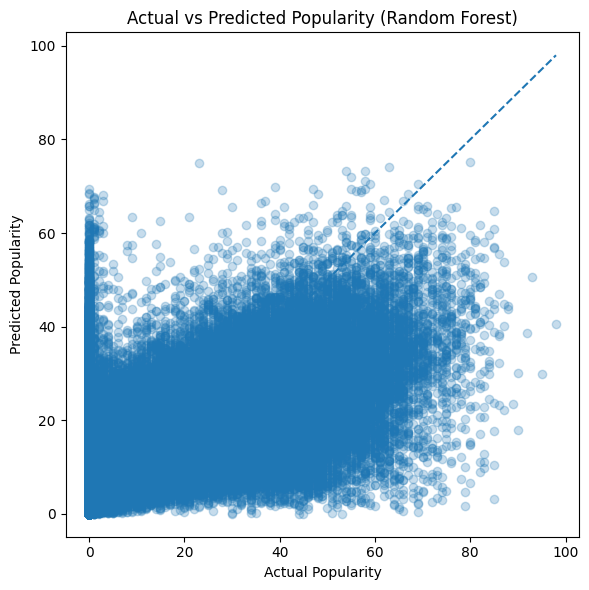

In [12]:
import matplotlib.pyplot as plt

best_model_name = "Random Forest"
y_pred_best = y_pred_rf

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.25)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title(f"Actual vs Predicted Popularity ({best_model_name})")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.tight_layout()
plt.show()


## Regression Diagnostic: Residuals Plot

Residuals represent prediction error (Actual − Predicted).
A good model should show residuals scattered randomly around zero with no clear pattern.


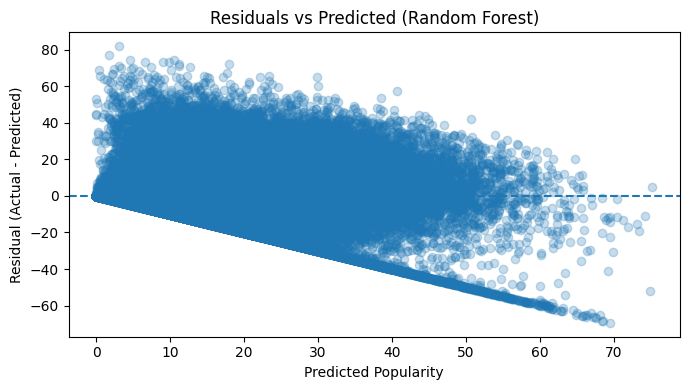

In [13]:
residuals = y_test - y_pred_best

plt.figure(figsize=(7,4))
plt.scatter(y_pred_best, residuals, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs Predicted ({best_model_name})")
plt.xlabel("Predicted Popularity")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


## Model Explainability: Top Drivers of Predicted Popularity

To support decision-making, we identify which features contribute most to the model’s predictions.
This helps translate model output into guidance artists can actually use.


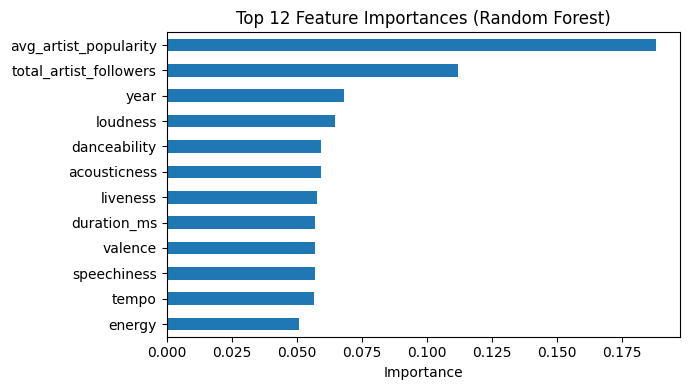

In [14]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(7,4))
importances.sort_values().plot(kind="barh")
plt.title("Top 12 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


Key Regression Takeaways

Song popularity is partially predictable
Regression models explain a meaningful portion of Spotify popularity, but a large share of performance is driven by external factors not captured in the data (e.g., marketing, playlists, virality).

Artist reach materially improves predictions
Audio features (tempo, energy, danceability) matter, but adding artist-level indicators such as follower count and prior popularity significantly strengthens model performance.

Nonlinear models outperform simple baselines
Ensemble models (Random Forest and Gradient Boosting) outperform linear regression, confirming that relationships between audio features, artist traction, and popularity are nonlinear.

Results support guidance—not certainty
Predictions are best positioned as probabilistic decision support to inform release timing and promotion strategy, rather than precise forecasts of success.

In [15]:
!pip -q install kagglehub

import kagglehub
import os
import pandas as pd

spotify_dir = kagglehub.dataset_download(
    "serkantysz/550k-spotify-songs-audio-lyrics-and-genres"
)

songs = pd.read_csv(os.path.join(spotify_dir, "songs.csv"), engine="python", on_bad_lines="skip")
artists = pd.read_csv(os.path.join(spotify_dir, "artists.csv"), engine="python", on_bad_lines="skip")

hits_2024 = pd.read_csv(
    "/content/hits_2024.csv",
    engine="python",
    on_bad_lines="skip",
    encoding="cp1252"
)

print(songs.shape, artists.shape, hits_2024.shape)

Using Colab cache for faster access to the '550k-spotify-songs-audio-lyrics-and-genres' dataset.
(550622, 24) (71440, 6) (4600, 29)


In [16]:
dfs = [(k, v.shape) for k, v in list(globals().items()) if isinstance(v, pd.DataFrame)]
pd.DataFrame(dfs, columns=["dataframe", "shape"]).sort_values("shape", ascending=False)

,dataframe,shape
5,songs_processed,"(550622, 25)"
2,songs,"(550622, 24)"
7,X,"(550622, 24)"
8,X_train,"(440497, 24)"
9,X_test,"(110125, 24)"
3,artists,"(71440, 6)"
4,hits_2024,"(4600, 29)"
1,__,"(5, 25)"
6,_6,"(5, 25)"
0,_,"(3, 4)"


In [18]:
# -----------------------------
# EXECUTIVE DATA SAMPLE
# -----------------------------

sample_cols = [

    "danceability",
    "energy",
    "tempo",
    "valence",
    "popularity"
]

sample_cols = [c for c in sample_cols if c in songs.columns]

executive_sample = songs[sample_cols].sample(12, random_state=42)

executive_sample

,danceability,energy,tempo,valence,popularity
313554,0.397,0.974,104.822,0.1260,10
210119,0.705,0.718,121.982,0.6550,26
136837,0.546,0.992,105.063,0.2590,20
460801,0.365,0.937,149.410,0.4740,0
19995,0.654,0.836,117.981,0.5420,20
187636,0.268,0.345,163.271,0.3580,24
204993,0.340,0.596,148.222,0.1170,36
57197,0.216,0.866,173.701,0.3650,0
192514,0.430,0.983,145.056,0.0604,45
103714,0.744,0.805,106.503,0.9450,18


In [ ]:
executive_sample.to_csv("executive_sample.csv", index=False)

In [ ]:
executive_sample.round(3)

Clean Artists Column for Executive Table

In [30]:
import re

def clean_artists(val):
    if pd.isna(val):
        return ""

    s = str(val).strip()

    # Remove brackets
    s = s.strip("[]")

    # Remove quotes
    s = s.replace('"', "").replace("'", "")

    # Remove extra whitespace
    s = re.sub(r"\s+", " ", s)

    return s

# Apply cleaning
songs["artists"] = songs["artists"].apply(clean_artists)

# EXECUTIVE DATA SAMPLE


sample_cols = [
    "name",
    "artists",
    "danceability",
    "energy",
    "tempo",
    "valence",
    "total_artist_followers",
    "popularity"
]

executive_sample = (
    songs[sample_cols]
    .sample(12, random_state=42)
    .reset_index(drop=True)
)

executive_sample

,name,artists,danceability,energy,tempo,valence,total_artist_followers,popularity
0,Naive Monarch,Poison The Well,0.397,0.974,104.822,0.1260,123547,10
1,I Can't Live Without You,Angelique,0.705,0.718,121.982,0.6550,1024,26
2,Erase It All,iwrestledabearonce,0.546,0.992,105.063,0.2590,124624,20
3,The Majestic,Superchunk,0.365,0.937,149.410,0.4740,86163,0
4,Ain't What It Used To Be,Billy Currington,0.654,0.836,117.981,0.5420,2780191,20
5,Have A Heart,Charlie Rich,0.268,0.345,163.271,0.3580,250258,24
6,How Great Is Your Love - Live,"Passion, Kristian Stanfill",0.340,0.596,148.222,0.1170,667351,36
7,Black Plant,"The Last Shadow Puppets, Alex Turner, Miles Kane",0.216,0.866,173.701,0.3650,2542282,0
8,Hell In The Hallways,Ice Nine Kills,0.430,0.983,145.056,0.0604,1213408,45
9,Dalis Car,Dalis Car,0.744,0.805,106.503,0.9450,16161,18
